In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
 #   for filename in filenames:
  #      print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Load Dataset

In [2]:
DATA_PATH = "/kaggle/input/datasets/anoopkumar279/credit-scoring/"

df = pd.read_excel(DATA_PATH + "a_Dataset_CreditScoring.xlsx")

print("Dataset Loaded Successfully")
print(df.shape)

df.head()

Dataset Loaded Successfully
(3000, 30)


,TARGET,ID,DerogCnt,CollectCnt,BanruptcyInd,InqCnt06,InqTimeLast,InqFinanceCnt24,TLTimeFirst,TLTimeLast,...,TL50UtilCnt,TLBalHCPct,TLSatPct,TLDel3060Cnt24,TLDel90Cnt24,TLDel60CntAll,TLOpenPct,TLBadDerogCnt,TLDel60Cnt24,TLOpen24Pct
0,1,582,3,3,0,4,0.0,5,117,27,...,3.0,0.9179,0.2083,2,3,7,0.2083,4,4,0.0000
1,1,662,15,9,0,3,1.0,3,14,14,...,1.0,0.8000,0.0000,0,0,0,1.0000,12,0,1.0000
2,1,805,0,0,0,1,5.0,1,354,7,...,5.0,0.3552,0.6538,0,1,1,0.7308,1,1,0.5263
3,1,1175,8,5,0,6,1.0,10,16,4,...,3.0,0.9127,0.2500,1,1,1,0.7500,7,1,1.3333
4,1,1373,3,1,0,9,0.0,8,130,52,...,1.0,1.2511,0.0000,0,1,4,0.1429,3,1,0.0000


## Dataset Information

In [3]:
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nStatistical Summary:\n")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TARGET           3000 non-null   int64  
 1   ID               3000 non-null   int64  
 2   DerogCnt         3000 non-null   int64  
 3   CollectCnt       3000 non-null   int64  
 4   BanruptcyInd     3000 non-null   int64  
 5   InqCnt06         3000 non-null   int64  
 6   InqTimeLast      2812 non-null   float64
 7   InqFinanceCnt24  3000 non-null   int64  
 8   TLTimeFirst      3000 non-null   int64  
 9   TLTimeLast       3000 non-null   int64  
 10  TLCnt03          3000 non-null   int64  
 11  TLCnt12          3000 non-null   int64  
 12  TLCnt24          3000 non-null   int64  
 13  TLCnt            2997 non-null   float64
 14  TLSum            2960 non-null   float64
 15  TLMaxSum         2960 non-null   float64
 16  TLSatCnt         2996 non-null   float64
 17  TLDel60Cnt    

## Target Variable

TARGET
0    2500
1     500
Name: count, dtype: int64


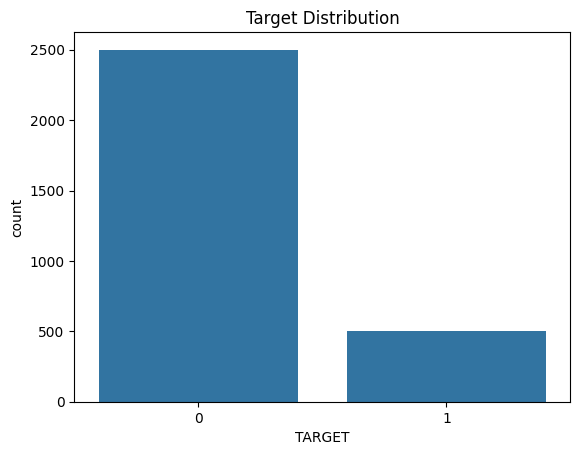

In [4]:
print(df["TARGET"].value_counts())

sns.countplot(x="TARGET", data=df)
plt.title("Target Distribution")
plt.show()

## Handling Missing Values

In [5]:
X = df.drop(columns=["TARGET","ID"])
y = df["TARGET"]

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Missing values handled successfully.")

Missing values handled successfully.


## Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (2400, 28)
Testing Shape : (600, 28)


## Logistic Regression

In [9]:
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=5000, random_state=42)

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Accuracy : 0.8333333333333334
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       500
           1       0.50      0.20      0.29       100

    accuracy                           0.83       600
   macro avg       0.68      0.58      0.60       600
weighted avg       0.80      0.83      0.80       600



## Confusion Matrix

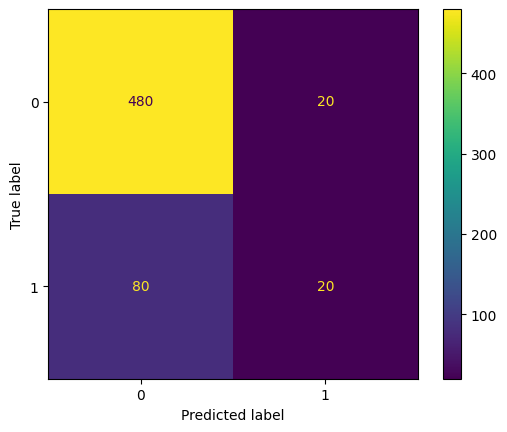

In [10]:
cm = confusion_matrix(y_test,pred_lr)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

## Decision Tree

In [11]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

print("Accuracy :",accuracy_score(y_test,pred_dt))

print(classification_report(y_test,pred_dt))

Accuracy : 0.7516666666666667
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       500
           1       0.25      0.24      0.24       100

    accuracy                           0.75       600
   macro avg       0.55      0.55      0.55       600
weighted avg       0.75      0.75      0.75       600



## Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy: 0.8283333333333334
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       500
           1       0.47      0.24      0.32       100

    accuracy                           0.83       600
   macro avg       0.67      0.59      0.61       600
weighted avg       0.80      0.83      0.80       600



## Compare Models

In [18]:
 
print("Logistic Regression :",accuracy_score(y_test,pred_lr))

print("Decision Tree :",accuracy_score(y_test,pred_dt))

print("Random Forest :",accuracy_score(y_test,pred_rf))

Logistic Regression : 0.8333333333333334
Decision Tree : 0.7516666666666667
Random Forest : 0.8283333333333334


## Feature Importance

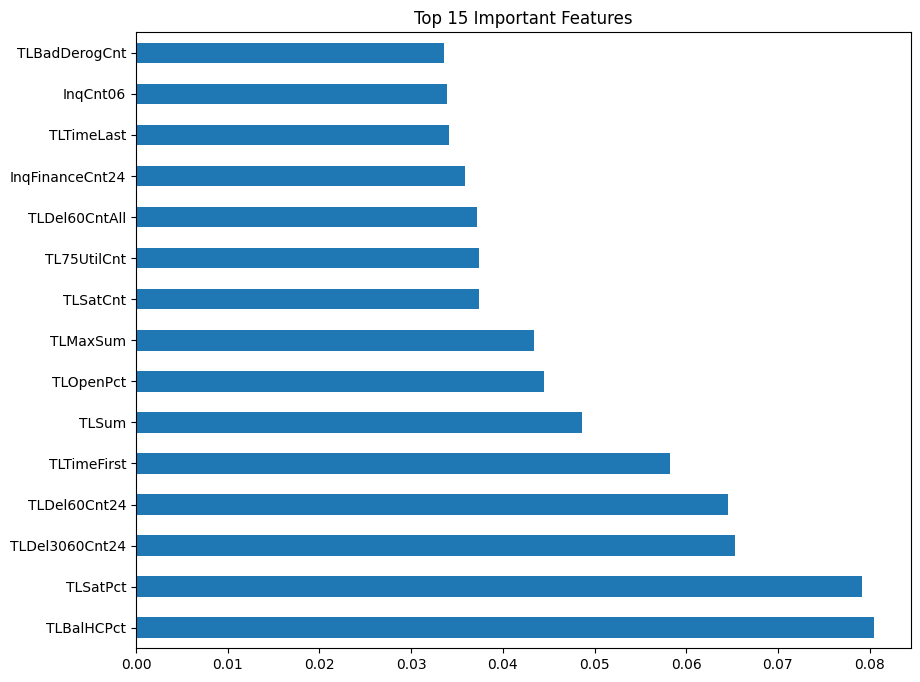

In [19]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(15).plot(kind="barh")

plt.title("Top 15 Important Features")

plt.show()

## Predict New Customer

In [20]:
new_customer = X.iloc[[0]]

prediction = rf.predict(new_customer)

if prediction[0]==1:
    print("High Credit Risk")
else:
    print("Low Credit Risk")



High Credit Risk


## Save Model

In [21]:
import joblib

joblib.dump(rf,"Credit_Scoring_Model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
